# Research question 1: comparative field accuracy

The Insight system converts customer-agent conversations into a structured business record with five fields (intent, issue_type, sentiment, resolution_status, agent_action). It implements three competing extraction pipelines: P1, a supervised TF-IDF classifier; P2, an LLM that only sees the five most relevant conversation lines per field and must cite them; P3, an LLM that sees the whole conversation.

How accurately the measure (per field) for each pipeline extracts the correct value, against gold labels derived from human annotations, on the same test conversations for all three.

The numbers come from `evaluation/rq1/out/` (produced by `evaluation/run.py`).

In [1]:
# The repository root is the first parent directory holding docker-compose.yml
import json
from pathlib import Path

REPO = Path.cwd().resolve()
while not REPO.joinpath("docker-compose.yml").exists():
  REPO = REPO.parent

STORE = REPO.joinpath("evaluation", "out", "predictions", "v1")
SCORES = REPO.joinpath("evaluation", "rq1", "out", "scores.json")
DATASETS = REPO.joinpath("dataprep", "out", "testing")

cells = len(list(STORE.glob("*.json"))) if STORE.exists() else 0
print(f"{cells} v1 prediction cells stored")

1461 v1 prediction cells stored


## The scores

Why this output: this table is the direct answer to rq1, it ranks the three pipelines per field.

How to read them:
- `accuracy` share of scored records where the prediction equals gold
- `macro_f1` per-class f1 averaged over the classes that appear in gold, so a pipeline can not look good by only getting the most common class right
- `scored` records with gold and a complete prediction
- `not_complete` failed or timed out cells, never counted as wrong answers

Each batch scores only the fields it has trustworthy gold for: abcd-text has intent, issue_type, agent_action; maia-text has sentiment, resolution_status; hvb-audio has intent.

In [2]:
if not SCORES.exists():
  print("no rq1 scores yet; run evaluation/run.py first")
else:
  scores = json.loads(SCORES.read_text())
  print(f"{'batch':<12} {'pipeline':<9} {'field':<18} {'accuracy':<9} {'macro_f1':<9} {'scored':<7} not_complete")
  for batch, pipelines in scores.items():
    for pipeline, per_field in pipelines.items():
      for field, s in per_field.items():
        acc = f"{s['accuracy']:.2f}" if s["accuracy"] is not None else "-"
        f1 = f"{s['macro_f1']:.2f}" if s["macro_f1"] is not None else "-"
        print(f"{batch:<12} {pipeline:<9} {field:<18} {acc:<9} {f1:<9} {s['scored']:<7} {s['not_complete']}")

batch        pipeline  field              accuracy  macro_f1  scored  not_complete
abcd-text    p1        agent_action       0.84      0.80      186     0
abcd-text    p1        intent             0.94      0.88      174     0
abcd-text    p1        issue_type         0.91      0.87      186     0
abcd-text    p2        agent_action       0.26      0.35      186     0
abcd-text    p2        intent             0.44      0.30      174     0
abcd-text    p2        issue_type         0.34      0.33      186     0
abcd-text    p3        agent_action       0.53      0.45      186     0
abcd-text    p3        intent             0.74      0.57      174     0
abcd-text    p3        issue_type         0.61      0.51      186     0
hvb-audio    p1        intent             0.77      0.67      26      0
hvb-audio    p2        intent             0.23      0.33      26      0
hvb-audio    p3        intent             0.96      0.96      26      0
maia-text    p1        resolution_status  0.77      0

## The picture

Why this output: the winner per field should be visible at a glance, one fixed color per pipeline across all four notebooks. Exact numbers stay in the table above.

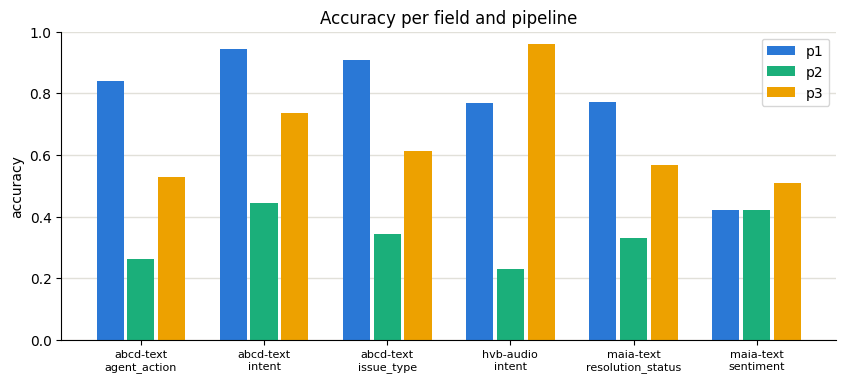

In [3]:
# %pip install plt
import matplotlib.pyplot as plt

COLORS = {"p1": "#2a78d6", "p2": "#1baf7a", "p3": "#eda100"}

if not SCORES.exists():
  print("no rq1 scores yet; run evaluation/run.py first")
else:
  scores = json.loads(SCORES.read_text())

  # One group per batch and field, in the order the table prints them
  groups = []
  for batch, pipelines in scores.items():
    for pipeline, per_field in pipelines.items():
      for field in per_field:
        if (batch, field) not in groups:
          groups.append((batch, field))

  fig, ax = plt.subplots(figsize=(10, 4))
  for offset, pipeline in enumerate(("p1", "p2", "p3")):
    xs = []
    ys = []
    for index, (batch, field) in enumerate(groups):
      s = scores[batch].get(pipeline, {}).get(field)
      if s is not None and s["accuracy"] is not None:
        xs.append(index + (offset - 1) * 0.25)
        ys.append(s["accuracy"])
    ax.bar(xs, ys, width=0.22, color=COLORS[pipeline], label=pipeline)

  ax.set_xticks(range(len(groups)))
  ax.set_xticklabels([f"{batch}\n{field}" for batch, field in groups], fontsize=8)
  ax.set_ylim(0, 1)
  ax.set_ylabel("accuracy")
  ax.set_title("Accuracy per field and pipeline")
  ax.legend()
  ax.grid(axis="y", color="#e1e0d9", linewidth=1)
  ax.set_axisbelow(True)
  ax.spines["top"].set_visible(False)
  ax.spines["right"].set_visible(False)
  plt.show()

## One record up close

The conversation exactly as the pipelines saw it, then the gold answers next to what each pipeline said. Change `sample_index` to inspect another record.

In [4]:
sample_index = 0
samples = sorted(STORE.glob("*__text__p2.json")) + sorted(STORE.glob("*__oracle__p2.json")) if STORE.exists() else []
if not samples:
  print("no p2 cells stored yet")
else:
  sample = samples[sample_index]
  batch, rest = sample.stem.split("__", 1)
  record_id, variant, _ = rest.rsplit("__", 2)

  record = json.loads(DATASETS.joinpath(batch, "records", f"{record_id}.json").read_text())
  print(f"record {record_id} from {batch}\n")
  for turn in record["turns"][:8]:
    print(f"{turn['speaker']:>9}: {turn['text']}")
  if len(record["turns"]) > 8:
    print(f"... {len(record['turns']) - 8} more turns")

  gold = json.loads(DATASETS.joinpath(batch, "gold.json").read_text())[record_id]
  predictions = {}
  for pipeline in ("p1", "p2", "p3"):
    path = STORE.joinpath(f"{batch}__{record_id}__{variant}__{pipeline}.json")
    predictions[pipeline] = json.loads(path.read_text()) if path.exists() else {"fields": {}, "status": "not run"}

  fields = [f for f in gold if not f.endswith("_source") and f != "speakers"]
  print(f"\n{'field':<18} {'gold':<20} {'p1':<20} {'p2':<20} {'p3':<20}")
  for field in fields:
    row = f"{field:<18} {str(gold[field]):<20}"
    for pipeline in ("p1", "p2", "p3"):
      row += f"{str(predictions[pipeline]['fields'].get(field, '')):<20}"
    print(row)

record abcd-10012 from abcd-text

    agent: Hello, how may I help you today?
 customer: Hello. I need to check on a recent refund for a return i did.
    agent: I see, let's see what we can found out.  One moment.
    agent: May I have your full name or account ID?
 customer: yes it's Rodriguez Domingo and i don't know my account id.
    agent: That is fine, I will need to validate your purchase.  May I have your email address and order ID?
    agent: Oh and your username please as well.
 customer: sure my email is rd449161@email.com and my username is rd449161
... 10 more turns

field              gold                 p1                   p2                   p3                  
intent             refund_request      refund_request      unknown             refund_request      
issue_type         product_defect      product_defect      unknown             none                
agent_action       none                none                provide_information provide_information 


## What to conclude

The scores table is the answer to rq1: per field, the pipeline with the highest accuracy and macro-f1 is the best extractor for that field. Judge each number together with its `scored` count, a difference on 26 records means less than one on 186. The machine-readable numbers live in `evaluation/rq1/out/scores.json` and `results.csv`.